In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df =pd.read_csv("customer_churn_dataset-testing-master.csv")

# Data Cleaning and EDA

In [4]:
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0
...,...,...,...,...,...,...,...,...,...,...,...,...
64369,64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64370,64371,37,Male,6,1,5,22,Standard,Annual,923,9,1
64371,64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64372,64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1


In [5]:
df.isnull().sum() # no null values

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [6]:
df.duplicated().sum()# no duplicate values

np.int64(0)

In [7]:
df.shape

(64374, 12)

In [8]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [9]:
df.drop(columns=["CustomerID"])

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,53,Female,58,24,9,2,Standard,Annual,533,18,0
...,...,...,...,...,...,...,...,...,...,...,...
64369,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64370,37,Male,6,1,5,22,Standard,Annual,923,9,1
64371,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64372,50,Female,18,19,7,22,Standard,Monthly,540,13,1


In [10]:
number_col = df.select_dtypes(include = ['number'])

In [11]:
# For Correlation between each pair
number_col.corr()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
CustomerID,1.000000,0.043287,0.103296,-0.062699,0.164175,0.290684,-0.037068,-0.003718,0.529832
Age,0.043287,1.000000,-0.007763,-0.038331,0.005014,-0.016132,0.006490,-0.000148,0.063457
Tenure,0.103296,-0.007763,1.000000,0.023485,0.060065,0.055963,0.009474,0.005770,0.195327
Usage Frequency,-0.062699,-0.038331,0.023485,1.000000,-0.014072,0.031132,0.001527,-0.009192,-0.115098
Support Calls,0.164175,0.005014,0.060065,-0.014072,1.000000,0.064298,0.021750,0.001666,0.304631
Payment Delay,0.290684,-0.016132,0.055963,0.031132,0.064298,1.000000,-0.031119,-0.008076,0.557386
Total Spend,-0.037068,0.006490,0.009474,0.001527,0.021750,-0.031119,1.000000,-0.007692,-0.078867
Last Interaction,-0.003718,-0.000148,0.005770,-0.009192,0.001666,-0.008076,-0.007692,1.000000,-0.002818
Churn,0.529832,0.063457,0.195327,-0.115098,0.304631,0.557386,-0.078867,-0.002818,1.000000


In [12]:
df["Churn"].value_counts() 

Churn
0    33881
1    30493
Name: count, dtype: int64

'balanced dataset'

Text(0.5, 1.0, 'Churn percentage')

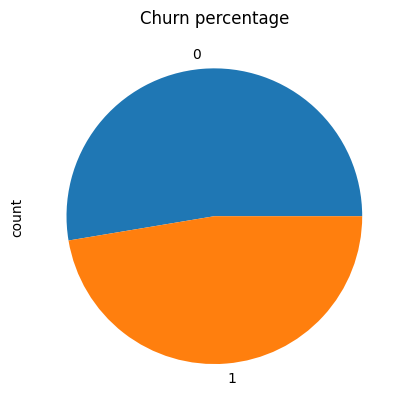

In [13]:
df['Churn'].value_counts().plot(kind = 'pie')
plt.title('Churn percentage')

In [14]:
# Filter the DataFrame based on the conditions
premium_annual_churn_count = df[
    (df['Subscription Type'] == 'Premium') & 
    (df['Contract Length'] == 'Quaterly') & 
    (df['Churn'] == 1)
].shape[0]

print("Count of rows with Premium Subscription, Annual Contract Length, and Churn:", premium_annual_churn_count)

Count of rows with Premium Subscription, Annual Contract Length, and Churn: 0


In [15]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [16]:
df.groupby('Churn')['Total Spend'].mean()
df.groupby('Churn')['Total Spend'].median()

Churn
0    568.0
1    491.0
Name: Total Spend, dtype: float64

In [17]:
df.groupby('Churn')['Total Spend'].std()

Churn
0    259.621052
1    260.555775
Name: Total Spend, dtype: float64

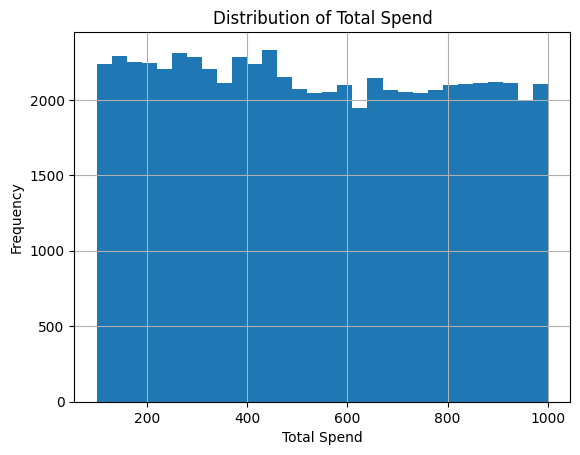

In [18]:
df['Total Spend'].hist(bins=30)
plt.title('Distribution of Total Spend')
plt.xlabel('Total Spend')
plt.ylabel('Frequency')
plt.show()

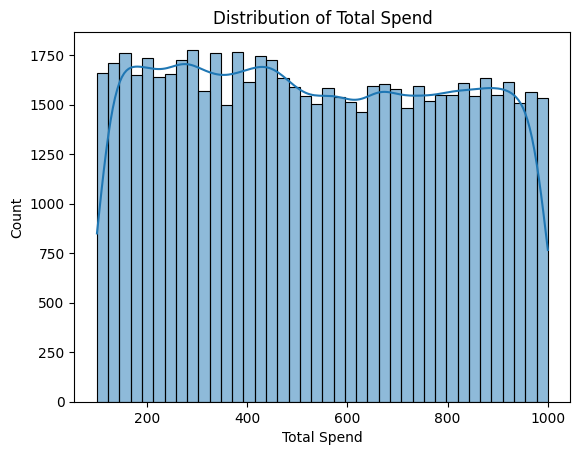

In [19]:
sns.histplot(df['Total Spend'], kde=True)
plt.title('Distribution of Total Spend')
plt.show()

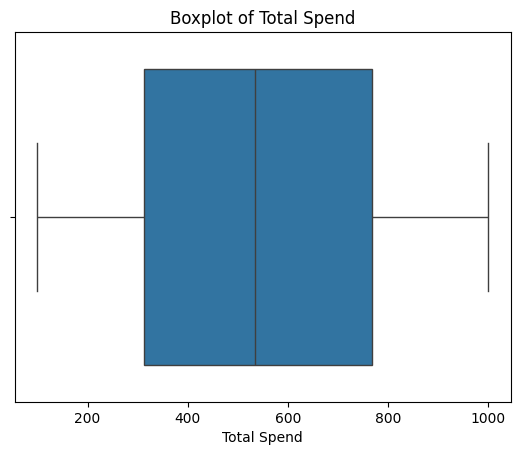

In [20]:
# Checking Outlier using boxplot visualisation
sns.boxplot(x=df['Total Spend'])
plt.title('Boxplot of Total Spend')
plt.show()

In [21]:
# (IQR to find No of Outliers) 
# Total Spend No. of Outliers
Q1 = df['Total Spend'].quantile(0.25)  # First quartile
Q3 = df['Total Spend'].quantile(0.75)  # Third quartile
IQR = Q3 - Q1  # Interquartile range

# Define lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers = df[(df['Total Spend'] < lower_bound) | (df['Total Spend'] > upper_bound)]
print("Number of outliers:", outliers.shape[0])

Number of outliers: 0


In [22]:
# Skewness --- Tells Symmetry of Data (for Normal Dist. Skewness = 0)
# Kurtosis --- Tells peakdness of data (For Normal Dist. Kurtosis = 3)
from scipy.stats import skew, kurtosis

print("Skewness:", skew(df['Total Spend']))
print("Kurtosis:", kurtosis(df['Total Spend']))

Skewness: 0.0477452370540785
Kurtosis: -1.2128986618212296


**Total Spend is platykurtic**

**Total Spend is Right Skewed**

In [23]:
# Remove outliers
df_cleaned = df[(df['Total Spend'] >= lower_bound) & (df['Total Spend'] <= upper_bound)]
print("Shape after removing outliers:", df_cleaned.shape)

Shape after removing outliers: (64374, 12)


**Since No outliers df shape remains same**

In [24]:
df_cleaned.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


<Axes: xlabel='Churn,Gender'>

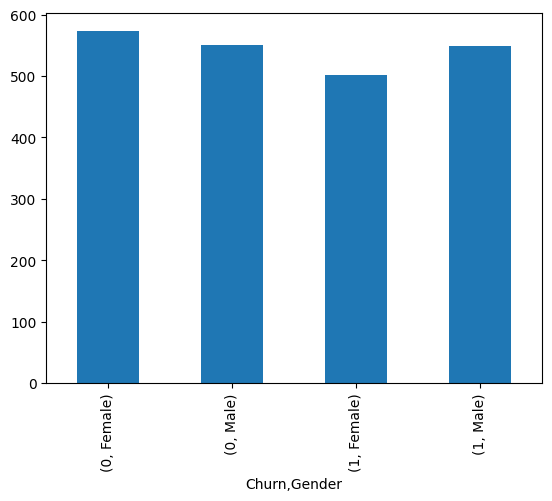

In [25]:
df.groupby(['Churn','Gender'])['Total Spend'].mean().plot(kind="bar")

## Model Training without Feature Engineering

In [26]:
df_cleaned.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [27]:
df_cleaned.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [28]:
y = df_cleaned['Churn']
X = df_cleaned[['Age',"Gender","Tenure","Total Spend","Support Calls",'Last Interaction','Subscription Type','Payment Delay',"Contract Length"]]

In [29]:
X.head()

,Age,Gender,Tenure,Total Spend,Support Calls,Last Interaction,Subscription Type,Payment Delay,Contract Length
0,22,Female,25,598,4,9,Basic,27,Monthly
1,41,Female,28,584,7,20,Standard,13,Monthly
2,47,Male,27,757,2,21,Premium,29,Annual
3,35,Male,9,232,5,18,Premium,17,Quarterly
4,53,Female,58,533,9,18,Standard,2,Annual


# Categorical Encoding

In [30]:
# Categorical to Numerical Encoding
# Female --- 1 , Male --- 0
# Basic -- 0 , Premium --- 1 , Standard --- 2
X['Gender']=X['Gender'].apply(lambda x:1 if x == "Female" else 0)
X['Subscription Type'] = X['Subscription Type'].astype('category').cat.codes
X['Contract Length'] = X['Contract Length'].astype('category').cat.codes

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19940\3257390828.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Gender']=X['Gender'].apply(lambda x:1 if x == "Female" else 0)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19940\3257390828.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Subscription Type'] = X['Subscription Type'].astype('category').cat.codes
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19940\3257390828.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from 

In [31]:
X.head()

,Age,Gender,Tenure,Total Spend,Support Calls,Last Interaction,Subscription Type,Payment Delay,Contract Length
0,22,1,25,598,4,9,0,27,1
1,41,1,28,584,7,20,2,13,1
2,47,0,27,757,2,21,1,29,0
3,35,0,9,232,5,18,1,17,2
4,53,1,58,533,9,18,2,2,0


In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2,random_state=33)

In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [34]:
X_train= scaler.fit_transform(X_train)

In [35]:
X_test = scaler.transform(X_test)

In [36]:
from sklearn.metrics import accuracy_score

def modelperformance(predictions):
    print("Accuracy score for model is {}".format(accuracy_score(y_test,predictions)))

In [37]:
# 1st model Logistic Regression 
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()

In [38]:
log_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [39]:
y_pred_logst = log_model.predict(X_test)
modelperformance(y_pred_logst)

Accuracy score for model is 0.8204271844660194


In [40]:
# 2nd model SVM 
from sklearn.svm import SVC
svm = SVC(kernel='linear')

In [41]:
svm.fit(X_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [42]:
y_pred_svm = svm.predict(X_test)
modelperformance(y_pred_svm)

Accuracy score for model is 0.8231456310679611


# Feature Engineering to improve Performance

In [43]:
df_cleaned.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [44]:
# Rebuild New dataframe including new Features.
df_new = df_cleaned[[
        "Age", "Gender", "Tenure", "Total Spend", "Support Calls",
        "Last Interaction", "Subscription Type", "Payment Delay",
        "Contract Length", "Churn"
    ]].copy()
# Avg Monthly Spend = Total Spend / Tenure 
df_new['Avg_Mon_spend'] = round(df_new['Total Spend'] / df_new['Tenure'].replace(0, np.nan),2)

# Add a new column 'Pay Delay Resolved' based on the condition if no then 0 else 1
df_new['Pay Delay Resolved'] = df_new['Payment Delay'].apply(lambda x: 0 if x > 20 else 1)

# Usage Frequency = last interaction / Support calls
df_new['Usage_Frequency'] = round(df_new['Tenure']/df_new['Last Interaction'],2)

# Display the updated DataFrame
df_new.head()

,Age,Gender,Tenure,Total Spend,Support Calls,Last Interaction,Subscription Type,Payment Delay,Contract Length,Churn,Avg_Mon_spend,Pay Delay Resolved,Usage_Frequency
0,22,Female,25,598,4,9,Basic,27,Monthly,1,23.92,0,2.78
1,41,Female,28,584,7,20,Standard,13,Monthly,0,20.86,1,1.40
2,47,Male,27,757,2,21,Premium,29,Annual,0,28.04,0,1.29
3,35,Male,9,232,5,18,Premium,17,Quarterly,0,25.78,1,0.50
4,53,Female,58,533,9,18,Standard,2,Annual,0,9.19,1,3.22


In [45]:
y_new= df_new['Churn']
X_new= df_new[['Age',"Gender","Tenure","Total Spend","Support Calls",'Last Interaction','Subscription Type','Payment Delay',"Contract Length","Avg_Mon_spend","Pay Delay Resolved","Usage_Frequency"]]

In [46]:
X_new['Gender']=X_new['Gender'].apply(lambda x:1 if x == "Female" else 0)
X_new['Subscription Type'] = X_new['Subscription Type'].astype('category').cat.codes
X_new['Contract Length'] = X_new['Contract Length'].astype('category').cat.codes

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19940\281739794.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_new['Gender']=X_new['Gender'].apply(lambda x:1 if x == "Female" else 0)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19940\281739794.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_new['Subscription Type'] = X_new['Subscription Type'].astype('category').cat.codes
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19940\281739794.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

In [47]:
X_new.head()

,Age,Gender,Tenure,Total Spend,Support Calls,Last Interaction,Subscription Type,Payment Delay,Contract Length,Avg_Mon_spend,Pay Delay Resolved,Usage_Frequency
0,22,1,25,598,4,9,0,27,1,23.92,0,2.78
1,41,1,28,584,7,20,2,13,1,20.86,1,1.40
2,47,0,27,757,2,21,1,29,0,28.04,0,1.29
3,35,0,9,232,5,18,1,17,2,25.78,1,0.50
4,53,1,58,533,9,18,2,2,0,9.19,1,3.22


*Splitting Dataset into training and test data*

*Applying Standardscaler for faster convergence*

In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_new,y_new, test_size =0.2,random_state=33)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [49]:
X_train= scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [50]:
# Dump the scaler pkl file for other use
import joblib
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

# Model Training with Hyperparameter Tuning

'`XGBOOST`'

In [51]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score
import numpy as np

# Example: assume X, y are your dataset features and labels
# X = df.drop('target', axis=1)
# y = df['target']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

# Base Model
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Hyperparameter Grid
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'min_child_weight': [1, 3, 5]
}

# Randomized Search (faster than full grid)
random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    n_iter=20,               # number of parameter settings sampled
    scoring='accuracy',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit
random_search.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", random_search.best_params_)

# Best Estimator
best_xgb_model = random_search.best_estimator_
best_xgb_params = random_search.best_params_


# Predictions
y_pred = best_xgb_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Test Data:", accuracy)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\ASUS\miniconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:17:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 5, 'colsample_bytree': 1.0}
Accuracy on Test Data: 0.9455533980582524


In [52]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[6786    7]
 [ 694 5388]]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      6793
           1       1.00      0.89      0.94      6082

    accuracy                           0.95     12875
   macro avg       0.95      0.94      0.94     12875
weighted avg       0.95      0.95      0.95     12875



In [60]:
# Save hyperparameters
import json
with open("xgb_best_params.json", "w") as f:
    json.dump(best_xgb_params, f, indent=4)

# Save trained model
joblib.dump(best_xgb_model, "xgboost_model_v1_best.pkl")

['xgboost_model_v1_best.pkl']

In [58]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_prob = best_xgb_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))

ROC-AUC: 0.986842547309543
PR-AUC: 0.9870585994077523


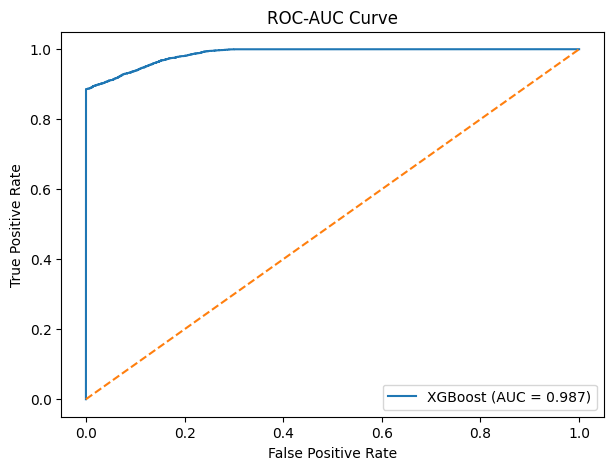

In [59]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.3f})")

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

y_prob = best_model.predict_proba(X_test)[:, 1]

for threshold in np.arange(0.1, 0.91, 0.05):
    
    y_pred_threshold = (y_prob >= threshold).astype(int)
    
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    
    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f}"
    )

Threshold: 0.10 | Precision: 0.780 | Recall: 0.995
Threshold: 0.15 | Precision: 0.807 | Recall: 0.984
Threshold: 0.20 | Precision: 0.836 | Recall: 0.974
Threshold: 0.25 | Precision: 0.851 | Recall: 0.967
Threshold: 0.30 | Precision: 0.863 | Recall: 0.959
Threshold: 0.35 | Precision: 0.935 | Recall: 0.914
Threshold: 0.40 | Precision: 0.986 | Recall: 0.890
Threshold: 0.45 | Precision: 0.996 | Recall: 0.887
Threshold: 0.50 | Precision: 0.999 | Recall: 0.886
Threshold: 0.55 | Precision: 1.000 | Recall: 0.885
Threshold: 0.60 | Precision: 1.000 | Recall: 0.884
Threshold: 0.65 | Precision: 1.000 | Recall: 0.884
Threshold: 0.70 | Precision: 1.000 | Recall: 0.884
Threshold: 0.75 | Precision: 1.000 | Recall: 0.884
Threshold: 0.80 | Precision: 1.000 | Recall: 0.884
Threshold: 0.85 | Precision: 1.000 | Recall: 0.884
Threshold: 0.90 | Precision: 1.000 | Recall: 0.884


'`Since for a company Predicting customer who is going to churn is important`'

 'Threshold = 0.30 is selected for better Performance in identifying person going to churn for XG Boost'

`Logistic Regression`

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
# Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)

# Beginner-friendly hyperparameters
param_dist = {
    'C': [0.01, 0.1, 1, 10, 100], # small c stronger regularization
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] # supports L1 and L2 and find optimal model coefficients
}

# Randomized Search
random_search_lr = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# Train
random_search_lr.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(random_search_lr.best_params_)

# Best CV score
print("Best CV Score:")
print(random_search_lr.best_score_)

# Best model
best_lr = random_search_lr.best_estimator_

# Test prediction
y_pred = best_lr.predict(X_test)

# Test accuracy
print("Test Accuracy:")
print(accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters:
{'solver': 'liblinear', 'penalty': 'l1', 'C': 0.1}
Best CV Score:
0.8200936729647614
Test Accuracy:
0.8278834951456311

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      6793
           1       0.82      0.82      0.82      6082

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875

